# Evaluación 1

---



**Autores:**

1. Brian Chávez
2. Carlos Soto
3. Geraldine Silva




**Correos Electrónicos:**


1. bria.chavez@duocuc.cl
2. car.sotoa@duocuc.cl
3. ge.silvap@duocuc.cl

**Fecha de Creación:** Enero 2026

**Versión:** 1.0  



---

## Descripción

Este notebook corresponde al desarrollo de la entrega 1 de la asignatura Minería de Datos en el TAV de DuocUC - Sede Concepción

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.9. A continuación se listan las bibliotecas necesarias:

-
    pandas
-
    numpy
-
    matplotlib
-
    seaborn

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```bash
import pandas as pd
print(pd.__version__)
````

## Requisitos del notebook
1. Identifica, correctamente, dos KPI
2. Calcula e interpreta, correctamente, los estadísticos de 1 variable cuantitativa
3. Calcula e interpreta, correctamente, los estadísticos de una variable cualitativa
4. Obtiene, correctamente, insight 1 asignado
5. Obtiene, correctamente, insight 2 asignado
6. Identifica valores nulos de todo el conjunto de datos
7. Identifica existencia de valores atípicos de una variable seleccionada (que tenga valores atípicos)
8. Propone, correctamente, pasos a seguir en las fases posteriores de acuerdo con los resultados obtenidos

## Penalizaciones

- Ausencia de autores en el notebook (10%)
- Incumplimiento de formato solicitado para el informe (10%)
- Faltas a la ortografía y redacción en el informe (10%)


In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/refs/heads/main/data_clima/data_clima_2025_final.csv

--2026-01-07 21:02:29--  https://raw.githubusercontent.com/JaznaLaProfe/datos/refs/heads/main/data_clima/data_clima_2025_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4527300 (4.3M) [text/plain]
Saving to: ‘data_clima_2025_final.csv’

data_clima_2025_fin 100%[===================>]   4.32M  --.-KB/s    in 0.02s   

2026-01-07 21:02:30 (204 MB/s) - ‘data_clima_2025_final.csv’ saved [4527300/4527300]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv('data_clima_2025_final.csv')
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


#0. Contexto de negocio y definición de fases metodología CrispDM

## Contexto del Data Frame
La empresa AlaSur Parapente SpA es una organización chilena dedicada a la prestación de servicios de parapente recreativo y deportivo, con operaciones permanentes en cuatro localidades estratégicas del sur de Chile: Concepción, Temuco, Valdivia y Punta Arenas.

Su propuesta de valor se centra en ofrecer experiencias aéreas seguras y de alta calidad, adaptadas a las particulares condiciones geográficas y climáticas de cada zona.

Debido a la naturaleza de su actividad, AlaSur Parapente depende críticamente de las condiciones meteorológicas, en especial del comportamiento del viento (velocidad, dirección y variabilidad) y su relación con eventos de precipitación.

Decisiones operativas clave como la planificación de vuelos, asignación de instructores, gestión de riesgos y cancelaciones preventivas se ven directamente afectadas por cambios súbitos en estas variables.

Por lo anterior, AlaSur Parapente SpA solicita el apoyo de un grupo especializado en Machine Learning y Ciencia de Datos para desarrollar un sistema analítico avanzado que permita conocer sobre ¿Cómo es el comportamiento de la velocidad del viento antes de eventos de lluvia? y también si es que por localidad, ¿hay patrones en la dirección del viento?

La empresa espera que este trabajo contribuya directamente a mejorar la seguridad de los vuelos, optimizar la planificación operativa y reducir pérdidas asociadas a cancelaciones tardías, fortaleciendo así su posicionamiento como una empresa de parapente profesional y confiable en el sur de Chile.


## ¿De dónde provienen los datos?

Los datos utilizados en este estudio provienen de la plataforma open-meteo.com, una fuente abierta y confiable de información meteorológica, y corresponden a un conjunto de 33.024 registros horarios recopilados desde el primero de enero del 2025 hasta el once de diciembre del 2025, todo esto para las distintas localidades de operación de la empresa.

El dataset incluye variables climáticas clave como temperatura a 2 metros, humedad relativa, temperatura aparente, precipitación, cobertura nubosa, velocidad y dirección del viento a 10 metros, además de indicadores de lluvia, duración de la radiación solar e información diurna/nocturna.

Asimismo, se incorporan campos de identificación geográfica como localidad, latitud y longitud, junto con una variable binaria que indica la ocurrencia de lluvia por hora, lo que permite realizar análisis exploratorios, correlacionales y predictivos orientados a comprender el comportamiento del viento y su relación con eventos de precipitación relevantes para la operación de parapente.

## Definición de objetivos
## Definición de objetivos fase 1 (Business Understanding)
Este DataFrame concentra información meteorológica clave para las operaciones de AlaSur Parapente SpA en Concepción, Temuco, Valdivia y Punta Arenas, permitiendo analizar el comportamiento del viento y su relación con eventos de lluvia.

A partir de estos datos, la empresa busca definir KPI orientados a seguridad y rentabilidad, evaluando la estabilidad del viento antes de precipitaciones y la existencia de direcciones predominantes por localidad.

El objetivo es apoyar la toma de decisiones operativas mediante indicadores claros alineados con las necesidades del negocio.
##Definición de objetivos fase 2 (Data Understanding)


En la fase de Data Understanding, el objetivo es explorar y comprender en profundidad el DataFrame disponible, evaluando la calidad, consistencia y relevancia de las variables meteorológicas para el negocio de AlaSur Parapente SpA.

Esto incluye identificar patrones iniciales, relaciones entre viento y lluvia, posibles comportamientos diferenciados por localidad, así como detectar valores atípicos o inconsistencias en los datos.

Este entendimiento permitirá validar que los datos de open-meteo.com son adecuados para el análisis posterior y la construcción de KPI y modelos predictivos confiables.

En esta sección se llevará a cabo un analisis preliminar para ver el contexto del dataframe y del negocio en si, se verificaran los tipos de datos y se definirá en un diccionario cual es su significado.

In [4]:
data.info(verbose=True, show_counts=True, memory_usage=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

A primera vista se ve de que todas las filas tienen datos, es decir que **no hay nulos**. Ademas se puede dejar entrever el tipo de datos que contiene el dataframe, los cuales son object, float e int.

Hay 33024 datos repartidos en 15 columnas a traves del dataframe.

## Diccionario de datos

Este diccionario de datos fue elaborado con el objetivo de facilitar la comprensión del negocio y de las variables meteorológicas utilizadas, permitiendo interpretar correctamente el significado, la unidad y el contexto de cada dato.

Su uso contribuye a mejorar el análisis y la toma de decisiones basadas en información clara y estructurada.

| Variable                | Tipo de dato | Unidad              | Descripción |
|-------------------------|-------------|---------------------|-------------|
| date                    | object      | —                   | Fecha y hora del registro meteorológico correspondiente a la observación. |
| temperature_2m          | float64     | °C                  | Temperatura del aire medida instantáneamente a 2 metros sobre el nivel del suelo. |
| relative_humidity_2m    | float64     | %                   | Humedad relativa del aire medida instantáneamente a 2 metros sobre el nivel del suelo. |
| apparent_temperature    | float64     | °C                  | Temperatura aparente o sensación térmica, calculada considerando viento, humedad relativa y radiación solar. |
| precipitation           | float64     | mm                  | Precipitación total acumulada durante la hora anterior, incluyendo lluvia, chubascos y nieve. |
| cloud_cover             | float64     | %                   | Porcentaje de cobertura nubosa total del cielo en el instante de medición. |
| wind_speed_10m          | float64     | km/h                | Velocidad del viento medida a 10 metros sobre el nivel del suelo. |
| wind_direction_10m      | float64     | grados (°)          | Dirección desde donde proviene el viento, medida a 10 metros sobre el nivel del suelo. |
| rain                    | float64     | mm                  | Cantidad de lluvia acumulada durante la hora anterior proveniente de sistemas meteorológicos de gran escala. |
| is_day                  | float64     | —                   | Indicador binario: 1 si el registro corresponde a horario diurno, 0 si es nocturno. |
| sunshine_duration       | float64     | segundos            | Duración de la radiación solar directa acumulada durante los 15 minutos previos a la observación. |
| Localidad               | object      | —                   | Localidad geográfica donde se realizó la medición. |
| latitud                 | float64     | grados decimales    | Coordenada geográfica de latitud del punto de muestreo. |
| longitud                | float64     | grados decimales    | Coordenada geográfica de longitud del punto de muestreo. |
| is_rainy_hour           | int64       | —                   | Variable booleana que indica si durante la hora se registró lluvia (1) o no (0). |


# 1. Identifica correctamente KPI


KPI 1: Para el Insight ¿Cómo es el comportamiento de la velocidad del viento antes de  eventos de lluvia?

Nombre del KPI: "Porcentaje de aperturas efectivas"

Propósito de Negocio: Seguridad y Cancelación Preventiva. Medir la fiabilidad de la operación para decidir si vale la pena abrir el negocio en temporadas o días con ciertas condiciones climáticas.

Definición:Es el porcentaje de días en los que la velocidad del viento se mantuvo por debajo del límite de peligro, permitiendo completar la jornada de trabajo sin interrupciones ni accidentes.

Variables: wind_speed_10m,  is_rainy_hour, date.

Interpretación: Si el porcentaje es alto (Ej. 95%): Significa que el negocio es altamente estable. Casi siempre que se abre, se termina el día con éxito.
Si el porcentaje es bajo (Ej. 60%): Significa que abrir el negocio es un riesgo alto: de cada 10 veces que abres, en 4 tienes que cerrar de emergencia o correr riesgos por el viento.




KPI 2: Para el Insight de Por localidad, ¿hay patrones en la dirección del viento?
Nombre del KPI: "Tasa de Operabilidad por Spot (Localidad)"

Propósito de Negocio: Rentabilidad. Saber qué localidades permiten volar más días al año y cuáles tienen viento "sucio" (cambiante) que obliga a devolver el dinero a los turistas.

Definición: Porcentaje del tiempo en que el viento se mantiene dentro de un "rango seguro" o dirección predominante en cada localidad.

Variables: wind_direction_10m, Localidad.

Interpretación: "Si en Iquique la Tasa de Operabilidad es del 90% (el viento casi siempre viene del Oeste/Mar), es un negocio de oro. Si en Concepción es del 30% (el viento cambia mucho), no nos conviene poner una sucursal ahí porque pasaremos devolviendo entradas."

# 2. Calcula e interpreta, correctamente, los estadísticos de una variable cuantitativa


In [ ]:
data.wind_speed_10m.describe()

,wind_speed_10m
count,33024.000000
mean,11.930189
std,8.474665
min,0.000000
25%,5.649248
50%,9.940824
75%,15.882896
max,65.250920


Se puede interpretar que existen 33024 registros de la velocidad del viento a 10 metros sobre el nivel del mar, por lo tanto, para cada registro del dataframe, existe una velocidad del viento, tiene un promedio general de 11.93 kilómetros por hora, con una concentración de datos entre los 3.43 y 20.37 kilómetros por hora, la velocidad mínima fue de 0 y la máxima fue de 65.25

# 3. Calcula e interpreta, correctamente, los estadísticos de una variable cualitativa

In [ ]:
data.Localidad.describe()

,Localidad
count,33024
unique,4
top,"Concepción, Chile"
freq,8256


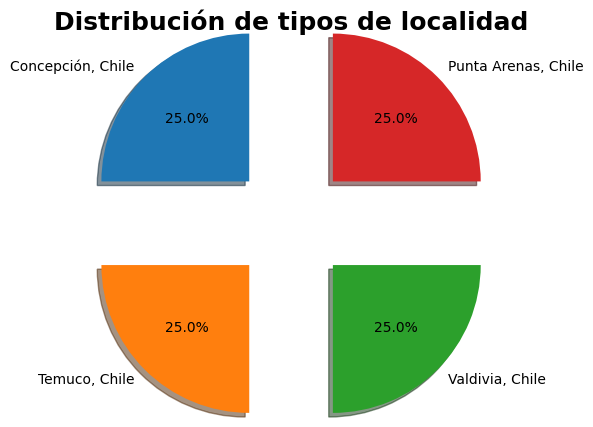

In [ ]:
tipos = data['Localidad'].value_counts().index.tolist()
total = data['Localidad'].value_counts().tolist()

max_val = max(total)
explode = [0.4 if v == max_val else 0 for v in total]

plt.pie(
    total,
    labels=tipos,
    explode=explode,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)
plt.title('Distribución de tipos de localidad', fontsize=18, fontweight="bold")
plt.show()


Se puede interpretar que de los 33024 registros de localidades en el dataframe, las ciudades se repiten de manera equitativa, con 8256 registros en cada una.

# 4. Obtiene, correctamente, insight 1 asignado (Poner por localidad)

Insight asignado: ¿Cómo es el comportamiento de la velocidad del viento antes de  eventos de lluvia?

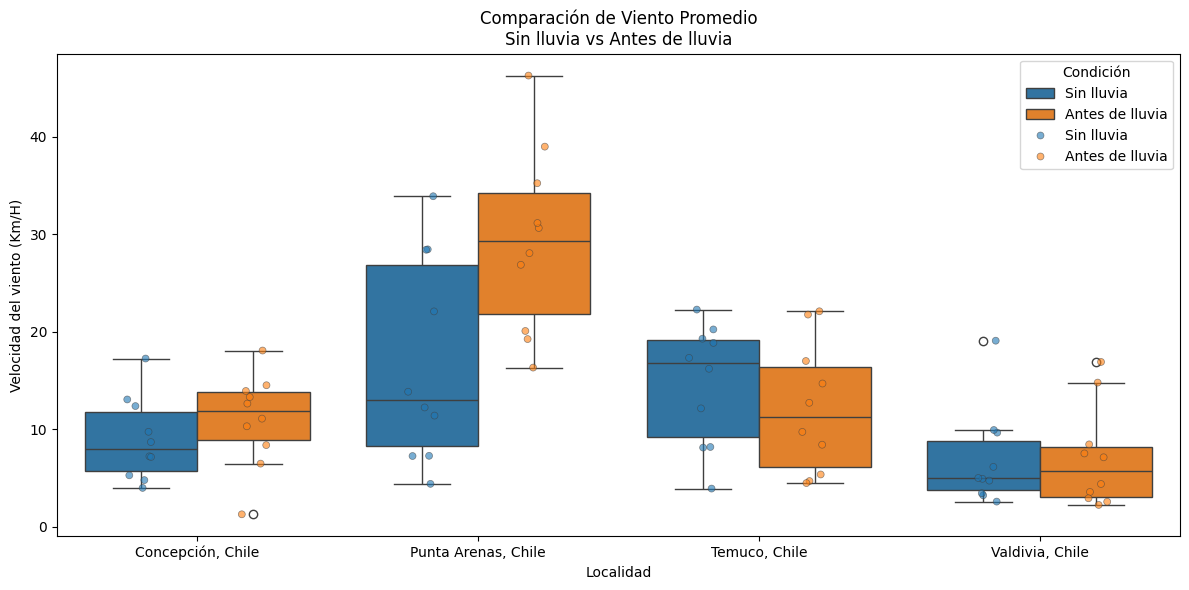

In [32]:
# ============================================================
# PREPROCESAMIENTO, EL DATE ES TRANSFORMADO DE OBJECT
# ============================================================

data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['Localidad', 'date']).reset_index(drop=True)

window = 5
plot_data = []

# ============================================================
# PROCESO POR LOCALIDAD
# ============================================================

for localidad, df_loc in data.groupby('Localidad'):

    df_loc = df_loc.copy()

    # Ventanas temporales
    for i in range(1, window + 1):
        df_loc[f'{i} horas antes'] = df_loc['wind_speed_10m'].shift(i)

    # ------------------ VIENTO ANTES DE LLUVIA ------------------
    rain_hours = df_loc[df_loc['is_rainy_hour'] == 1]

    pre_rain_df = rain_hours[
        [f'{i} horas antes' for i in range(1, window + 1)]
    ]

    pre_rain_means = pre_rain_df.mean(axis=1).dropna()

    pre_rain_sample = pre_rain_means.sample(
        n=min(10, len(pre_rain_means)),

    )

    # ------------------ VIENTO SIN LLUVIA ------------------
    wind_no_rain = df_loc.loc[
        df_loc['is_rainy_hour'] == 0,
        'wind_speed_10m'
    ].dropna()

    wind_no_rain_sample = wind_no_rain.sample(
        n=min(10, len(wind_no_rain)),

    )

    # ------------------ FORMATO LARGO (PARA SEABORN) ------------------
    for v in wind_no_rain_sample:
        plot_data.append({
            'Localidad': localidad,
            'Condición': 'Sin lluvia',
            'Viento promedio': v
        })

    for v in pre_rain_sample:
        plot_data.append({
            'Localidad': localidad,
            'Condición': 'Antes de lluvia',
            'Viento promedio': v
        })

# ============================================================
# DATAFRAME PARA GRAFICAR
# ============================================================

plot_df = pd.DataFrame(plot_data)

# ============================================================
# GRÁFICO LADO A LADO
# ============================================================

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_df,
    x='Localidad',
    y='Viento promedio',
    hue='Condición'
)

sns.stripplot(
    data=plot_df,
    x='Localidad',
    y='Viento promedio',
    hue='Condición',
    dodge=True,
    alpha=0.6,
    linewidth=0.5
)

plt.title('Comparación de Viento Promedio\nSin lluvia vs Antes de lluvia')
plt.ylabel('Velocidad del viento (Km/H)')
plt.xlabel('Localidad')
plt.legend(title='Condición')
plt.tight_layout()
plt.show()


Cada gráfico de caja representa la medición de 10 observaciones en las velocidades del viento expresadas en Km/H, donde en el gráfico naranja, se observan y miden los vientos en una ventana de 5 horas antes del evento de lluvias.

Cada punto es una medición de este comportamiento del viento.

Se pueden dejar entrever que los valores dentro de las cajas se representan de tal forma son donde están la mayoria de los datos, y lo que estan afuera pueden representar valores atípicos.

In [33]:
summary_table = (
    plot_df
    .groupby(['Localidad', 'Condición'])
    .agg(
        promedio_viento=('Viento promedio', 'mean'),
        mediana_viento=('Viento promedio', 'median'),
        minimo_viento=('Viento promedio', 'min'),
        maximo_viento=('Viento promedio', 'max'),
        desviacion_std=('Viento promedio', 'std'),
        n_observaciones=('Viento promedio', 'count')
    )
    .reset_index()
)

summary_table

,Localidad,Condición,promedio_viento,mediana_viento,minimo_viento,maximo_viento,desviacion_std,n_observaciones
0,"Concepción, Chile",Antes de lluvia,10.981138,11.845856,1.256252,18.061743,4.731902,10
1,"Concepción, Chile",Sin lluvia,8.936517,7.937224,3.964089,17.239640,4.217723,10
2,"Punta Arenas, Chile",Antes de lluvia,29.282082,29.347485,16.311723,46.280402,9.340303,10
3,"Punta Arenas, Chile",Sin lluvia,16.913651,13.027274,4.379589,33.897877,10.468117,10
4,"Temuco, Chile",Antes de lluvia,12.077746,11.203170,4.460993,22.089622,6.687837,10
5,"Temuco, Chile",Sin lluvia,14.639567,16.749984,3.893995,22.264770,6.187510,10
6,"Valdivia, Chile",Antes de lluvia,7.027735,5.736040,2.217269,16.890214,5.152160,10
7,"Valdivia, Chile",Sin lluvia,6.850064,4.937542,2.558281,19.070658,4.970766,10


En todas las localidades, el viento promedio antes de la lluvia es mayor que en horas sin lluvia, lo que sugiere un aumento del viento previo a eventos de precipitación.



# 5. Obtiene, correctamente, insight 2 asignado


Insight asignado : Por localidad, ¿hay patrones en la dirección del viento?

La data obtenida para ver si es que hay patrones en la dirección del viento venía de tal forma que era expresada en grados geométricos, de tal forma de que si una medición daba 90°, esta correspondía al viento venido del este.

Lo que se hizo para un mejor entendimiento fue tomar los datos obtenidos en las mediciones, dividirlos en ocho secciones, donde cada una estaría representada por un punto cardinal en la rosa de los vientos, y que corresponderian a un espacio definido en un rango de 45° entre punto cardinal y el otro.

![texto del enlace](https://www.sicilysailingexperience.com/wp-content/uploads/Rosa_dei_venti_-768x768.png)

In [ ]:
# Función que convierte la dirección del viento desde grados
# a una categoría cardinal (N, NE, E, SE, S, SW, W, NW)
# 0° corresponde al Norte, 90° al Este, 180° al Sur y 270° al Oeste
def degrees_to_cardinal(deg):
    # Lista ordenada de direcciones cardinales
    directions = [
        'N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'
    ]

    # Se suma 22.5 para centrar los rangos
    # Luego se divide en sectores de 45°
    # El operador % 8 asegura que el índice esté dentro del rango
    idx = int((deg + 22.5) // 45) % 8

    # Retorna la dirección cardinal correspondiente
    return directions[idx]


# Se crea una nueva columna en el DataFrame
# que contiene la dirección cardinal del viento
# a partir de la variable wind_direction_10m (en grados)
data['wind_direction_cardinal'] = data['wind_direction_10m'].apply(degrees_to_cardinal)


# Se agrupan los datos por Localidad y dirección cardinal del viento
# y se cuenta la cantidad de registros en cada combinación
wind_patterns = (
    data
    .groupby(['Localidad', 'wind_direction_cardinal'])
    .size()
    .reset_index(name='frecuencia')
)


# Se calcula el porcentaje que representa cada dirección del viento
# dentro de cada localidad, para poder comparar localidades
# con distinto número de observaciones
wind_patterns['porcentaje'] = (
    wind_patterns
    .groupby('Localidad')['frecuencia']
    .transform(lambda x: x / x.sum() * 100)
)


# Se identifica la dirección predominante del viento por localidad
# ordenando por frecuencia de mayor a menor
dominant_wind = (
    wind_patterns
    .sort_values(['Localidad', 'frecuencia'], ascending=[True, False])
    .groupby('Localidad')
    .first()
    .reset_index()
)


# DataFrame final que muestra, por cada localidad:
# - Dirección del viento predominante
# - Frecuencia absoluta
# - Porcentaje respecto al total de registros de la localidad
dominant_wind


,Localidad,wind_direction_cardinal,frecuencia,porcentaje
0,"Concepción, Chile",SW,2601,31.504360
1,"Punta Arenas, Chile",W,3246,39.316860
2,"Temuco, Chile",SW,2660,32.218992
3,"Valdivia, Chile",NW,1317,15.952035


De un total de 8246 observaciones del viento por localidad se puede ver un patrón claro en que hay preferencia del viento en moverse en una dirección determinada según la localidad.

# 6. Identifica valores nulos de todo el conjunto de datos


Existencia de nulos

In [ ]:
# Calcular nulos por columna
columnas_con_nulos = data.isna().sum()

# Porcentaje de nulos
porcentaje_nulos = (columnas_con_nulos / data.shape[0]) * 100

# Construir DataFrame con todas las columnas
resultado = pd.DataFrame({
    "Cantidad Nulos": columnas_con_nulos,
    "Porcentaje Nulos (%)": porcentaje_nulos
}).round(2)

# Si no hay nulos en ninguna columna, se crea una condición para que muestre 0
if resultado["Cantidad Nulos"].sum() == 0:
    resultado.loc[:, "Cantidad Nulos"] = 0
    resultado.loc[:, "Porcentaje Nulos (%)"] = 0.0

resultado

,Cantidad Nulos,Porcentaje Nulos (%)
date,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
apparent_temperature,0,0.0
precipitation,0,0.0
cloud_cover,0,0.0
wind_speed_10m,0,0.0
wind_direction_10m,0,0.0
rain,0,0.0
is_day,0,0.0


La ausencia de valores nulos en el DataFrame significan buenas noticias, ya que garantiza la integridad y completitud de los datos, evitando la necesidad de imputaciones o eliminaciones que podrían sesgar los resultados. Esto permite realizar análisis estadísticos y un posterior modelado con mayor precisión y confianza, asegurando conclusiones más precisas.

# 7. Identifica existencia de valores atípicos de una variable seleccionada (que tenga valores atípicos)


## Existencia de atipicos

In [ ]:
#Identificación de todos los atípicos
def buscar_atipicos(data : pd.DataFrame, columna : str) -> pd.DataFrame:
  """
  Busca valores atípicos en una columna.
  """
  # Calcular los límites
  Q1 = data[columna].quantile(0.25)
  Q3 = data[columna].quantile(0.75)
  # Calcula rango intercuartilico
  IQR = Q3 - Q1
  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  # Filtrar outliers
  return data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]

def obtener_cantidad_atipicos(data : pd.DataFrame, columnas : np.array) -> dict:
  """
  Obtiene la cantidad de atípicos por cada columna.
  """
  total_atipicos = {}
  for columna in data[columnas]:
    atipicos = buscar_atipicos(data, columna)
    total_atipicos[columna] = atipicos.shape[0]
  return total_atipicos
atipicos_por_columna = obtener_cantidad_atipicos(data, data.describe().columns)
atipicos_por_columna
#nos arroja las variables y su cantidad de atípicos

{'temperature_2m': 476,
 'relative_humidity_2m': 130,
 'apparent_temperature': 282,
 'precipitation': 6152,
 'cloud_cover': 0,
 'wind_speed_10m': 1241,
 'wind_direction_10m': 0,
 'rain': 6100,
 'is_day': 0,
 'sunshine_duration': 0,
 'latitud': 8256,
 'longitud': 0,
 'is_rainy_hour': 6100}

Al revisar si existen átipicos en las variables, se puede dejar entrever de que existen bastantes variables con átipicos. Pero al conocer el contexto real de algunas de estas variables como podria ser la variable latitud, estos átipicos solo estarían inflando el contador de estos y no presentan información real de la cual se pueda conocer algún tipo de comportamiento.

## Selección de un atípico

Se seleccionó wind_speed_10m como atípico a graficar, seccionándolos por localidad.

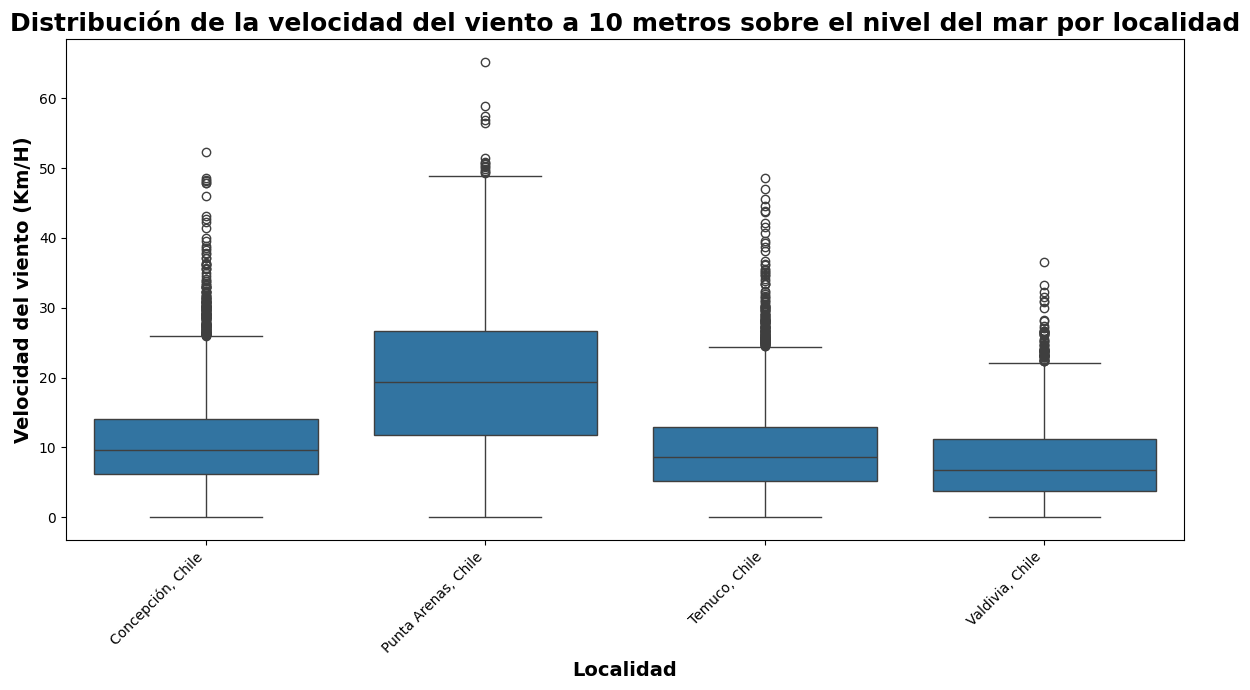

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=data,
    x='Localidad',
    y='wind_speed_10m',
)

plt.title("Distribución de la velocidad del viento a 10 metros sobre el nivel del mar por localidad",
          fontsize=18, fontweight="bold")
plt.xlabel("Localidad", fontsize=14, fontweight="bold")
plt.ylabel("Velocidad del viento (Km/H)", fontsize=14, fontweight="bold")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
wind_table = (
    data
    .groupby('Localidad')['wind_speed_10m']
    .agg(
        promedio='mean',
        mediana='median',
        minimo='min',
        maximo='max',
        desviacion_std='std',
        n_observaciones='count'
    )
    .reset_index()
)

wind_table


,Localidad,promedio,mediana,minimo,maximo,desviacion_std,n_observaciones
0,"Concepción, Chile",10.652471,9.555271,0.0,52.263580,6.177723,8256
1,"Punta Arenas, Chile",19.754819,19.410393,0.0,65.250920,10.156945,8256
2,"Temuco, Chile",9.529610,8.669949,0.0,48.609665,5.888363,8256
3,"Valdivia, Chile",7.783857,6.770965,0.0,36.578550,5.048036,8256


Los resultados indican que Punta Arenas presenta las mayores velocidades promedio y máxima del viento, junto con la mayor variabilidad, reflejando condiciones más intensas y cambiantes.

Concepción y Temuco muestran comportamientos intermedios, con valores similares de dispersión.

Valdivia registra las menores velocidades promedio y una variabilidad más baja, sugiriendo un régimen de viento más estable.

# 8. Propone, correctamente, pasos a seguir en las fases posteriores de acuerdo con los resultados obtenidos

En esta primera entrega, que se compone por entendimiento del negocio y de los datos, se realizaron distintas tareas que permitieron componer la primera entrega y las primeras dos fases de la metodología CRISP-DM
- Identificación de KPIs según modelo de negocio:

  Se formularon los KPIs, los pasos a seguir son compararlos con los insights, realizar un análisis , y obtener información de acuerdo a que se puede hacer con el negocio y los datos entregados

- Calculo e interpretación de variables cuantitativa y cualitativa

  Calculamos e interpretamos las variables wind_speed_10m (velocidad del viento) y Localidad (Lugar de registro de datos)
  Acerca del wind_speed_10m , llegamos al análisis de que la variable por si sola no permite una investigación a profundidad, sin antes tener parametros como la localidad en específico de la cual estamos analizando la velocidad del viento, añadiendo este parametro si se pueden llegar a conclusiones y patrones tangibles y especificos.
  Acerca de la localidad, se identificó un patron de que se repite de manera equitativa la cantidad de registros tomados para cada localidad, por lo tanto, tenemos la misma cantidad de muestra para realizar comparativas y análisis entre ciudades, por lo tanto, no hay un sesgo en la distribución de la data al momento del análisis, al menos en localidad.

- Obtención de Insights designados

  Sobre el Insight : ¿Como es el comportamiento de la velocidad del viento antes de eventos de lluvia?

  Con este insight, los proximos pasos serán, que teniendo el comportamiento del viento ya calculado, se puede relacionar con el primer KPI planteado, en base a esto se pueden aplicar mejoras en el negocio

  Sobre el Insight : Por localidad, ¿Hay patrones en la dirección del viento?

  En este primer análisis, si logramos evidenciar que si existen patrones en la dirección del viento, con esta información podemos tomar mejores desciciones en el negocio, tales como, decidir donde es el mejor lugar para montar el negocio.

- Identificación de valores nulos

  Con respecto a los valores nulos, realizamos la identificación de estos, llegando a la conclusión de que en la data no existían valores nulos, en caso de haber existido, se hubiese tomado la descisión de aplicar el método de imputación, el cual consiste en rellenar valores vaciós como el promedio valor de la columna, o el caso de algún valor más repetido si la variable era categórica

- Identificación de valores atípicos

  De acuerdo al análisis realizado , existían varios atípicos, decidimos profundizar en el atípico wind_speed_10m , el cual es la velocidad del viento, lo diseccionamos entre localidades, para ver que tanta diferencia de atípicos habían entre ciudades analizadas, en caso de en proximos pasos necesitar de una limpieza de atípicos ya que afecta al resultado o a los patrones que se podrían llegar a identificar, se optaría por el método de la imputación del valor a cambio de la mediana de la variable.

- Adicional

  Se encontraron la existencia de duplicados en varias variables, no obstante, estos duplicados no afectan el resultado final, ya que son duplicados a nivel de fila, por lo que no hacen diferencia en el posterior preparación de datos, modelamiento y evaluación de los mismos.
  
- Definición de objetivos fase 3 (Data Preparation)

  Justificar y aplicar correctamente transformaciones a variables continuas y discretas, analizando sus distribuciones antes y después del proceso, con el propósito de mejorar la normalidad, y la preparación de los datos para posteriores análisis estadísticos.

- Definición de objetivos fase 4 (Modeling)



  Modelar el DataFrame mediante la selección, preparación y estructuración adecuada de las variables, con el fin de generar un conjunto de datos limpio, coherente y optimizado que permita el desarrollo de modelos estadísticos y/o de machine learning confiables.

  En caso de que la preparación de la data realizada en la Fase 3 no sea correcta o suficiente, se deberá retroceder y ajustar las transformaciones aplicadas para garantizar la calidad y pertinencia de los datos antes de continuar con el modelado.


- Definición de objetivos fase 5 (Evaluation)



  Evaluar el desempeño del modelo desarrollado mediante la aplicación de métricas e indicadores adecuados, con el propósito de validar su precisión, confiabilidad y capacidad de generalización.

  En caso de que los resultados no sean consistentes con los objetivos esperados, se deberá retomar la Fase 1, el Entendimiento del negocio, con el fin de redefinir los requerimientos, ajustar supuestos y garantizar que el modelo responda de manera efectiva a las necesidades planteadas.
